# B_S2.4 — Null vs Signal Distribution Range Analysis (Filtered)

Same analysis as S2.3 but with configurable metric filtering:
- `EXCLUDE_BANDWIDTH`: remove buffer-width metrics
- `MERGE_DCOR_DCOV`: keep `distance_correlation`, drop `distance_covariance`
- `PREFER_DIV_Y_SD`: for metrics with both raw and `_div_y_sd` versions, keep only the normalized one
- `HIDE_NULL_CONSTANT`: hide metrics whose null 95% range ≈ 0 (e.g. MCN = constant under null)

| Mean response | Variance | Category | Model |
|:---:|:---:|:---|:---|
| Constant | Constant (indep. of X) | **true_null** | Y = c + σ₀ε |
| Changes with X | Constant (indep. of X) | **mean_only** | Y = f(X) + σ₀ε |
| Constant | Changes with X | **variance_only** | Y = c + σ(X)ε |
| Changes with X | Changes with X | **mean+variance** | Y = f(X) + σ(X)ε |

In [45]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

# ── Config switches ──────────────────────────────────────────
EXCLUDE_BANDWIDTH = True
MERGE_DCOR_DCOV = True
PREFER_DIV_Y_SD = True
HIDE_NULL_CONSTANT = True

VIZ_DIR = Path('output/S2.4')
VIZ_DIR.mkdir(parents=True, exist_ok=True)

print(f'EXCLUDE_BANDWIDTH  = {EXCLUDE_BANDWIDTH}')
print(f'MERGE_DCOR_DCOV    = {MERGE_DCOR_DCOV}')
print(f'PREFER_DIV_Y_SD    = {PREFER_DIV_Y_SD}')
print(f'HIDE_NULL_CONSTANT = {HIDE_NULL_CONSTANT}')

EXCLUDE_BANDWIDTH  = True
MERGE_DCOR_DCOV    = True
PREFER_DIV_Y_SD    = True
HIDE_NULL_CONSTANT = True


## Load Data

In [46]:
S1_DIR = Path('output/S1')
S2_DIR = Path('output/S2')

metrics_df = pd.read_parquet(S2_DIR / 'metrics_full.parquet')

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_main['source'] = 'main'
cases_null['source'] = 'null_expanded'
offset = cases_main['case_id'].max()
cases_null['case_id'] = cases_null['case_id'] + offset
cases_all = pd.concat([cases_main, cases_null], ignore_index=True)

label_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category', 'source']
df = metrics_df.merge(cases_all[label_cols], on=['case_id', 'source'], how='left')

non_metric = {'case_id', 'source', 'n_valid', 'family_id', 'snr', 'spread_pattern', 'x_distribution', 'category'}
metric_cols = sorted([c for c in df.columns if c not in non_metric])
n_before = len(metric_cols)

# ── Apply filters ────────────────────────────────────────────
if EXCLUDE_BANDWIDTH:
    bw_metrics = [m for m in metric_cols if 'buffer_width' in m]
    metric_cols = [m for m in metric_cols if 'buffer_width' not in m]
    print(f'EXCLUDE_BANDWIDTH: removed {len(bw_metrics)} buffer_width metrics')

if MERGE_DCOR_DCOV and 'distance_covariance' in metric_cols and 'distance_correlation' in metric_cols:
    metric_cols = [m for m in metric_cols if m != 'distance_covariance']
    print(f'MERGE_DCOR_DCOV: dropped distance_covariance (keeping distance_correlation)')

if PREFER_DIV_Y_SD:
    div_cols = [m for m in metric_cols if m.endswith('_div_y_sd')]
    raw_with_div = [m.replace('_div_y_sd', '') for m in div_cols if m.replace('_div_y_sd', '') in metric_cols]
    metric_cols = [m for m in metric_cols if m not in raw_with_div]
    print(f'PREFER_DIV_Y_SD: dropped {len(raw_with_div)} raw metrics (kept _div_y_sd versions)')
    for m in raw_with_div:
        print(f'  - {m}  →  {m}_div_y_sd')

if HIDE_NULL_CONSTANT:
    null_df = df[df['category'] == 'true_null']
    const_metrics = []
    for m in metric_cols:
        vals = null_df[m].dropna().values
        if len(vals) < 5:
            continue
        lo, hi = np.percentile(vals, [2.5, 97.5])
        if (hi - lo) < 1e-10:
            const_metrics.append(m)
    if const_metrics:
        metric_cols = [m for m in metric_cols if m not in const_metrics]
        print(f'HIDE_NULL_CONSTANT: removed {len(const_metrics)} metrics with null 95% range ≈ 0')
        for m in const_metrics:
            v = null_df[m].dropna().iloc[0]
            print(f'  - {m}  (constant = {v:.6f})')

print(f'\nMetrics: {n_before} → {len(metric_cols)}')

x_dists = sorted(df['x_distribution'].dropna().unique())
categories = ['true_null', 'mean_only', 'variance_only', 'mean+variance']
signal_cats = ['mean_only', 'variance_only', 'mean+variance']

print(f'Total cases: {len(df):,}')
print(f'Metric columns: {len(metric_cols)}')
print(f'x_distribution groups ({len(x_dists)}): {x_dists}')
print()
print(df['category'].value_counts())

EXCLUDE_BANDWIDTH: removed 16 buffer_width metrics
MERGE_DCOR_DCOV: dropped distance_covariance (keeping distance_correlation)
PREFER_DIV_Y_SD: dropped 8 raw metrics (kept _div_y_sd versions)
  - equal_count_bin_amplitude  →  equal_count_bin_amplitude_div_y_sd
  - equal_count_distribution_wasserstein_distance  →  equal_count_distribution_wasserstein_distance_div_y_sd
  - equal_width_bin_amplitude  →  equal_width_bin_amplitude_div_y_sd
  - equal_width_distribution_wasserstein_distance  →  equal_width_distribution_wasserstein_distance_div_y_sd
  - gam_curve_amplitude  →  gam_curve_amplitude_div_y_sd
  - gam_residual_sd  →  gam_residual_sd_div_y_sd
  - lowess_curve_amplitude  →  lowess_curve_amplitude_div_y_sd
  - lowess_residual_sd  →  lowess_residual_sd_div_y_sd
HIDE_NULL_CONSTANT: removed 2 metrics with null 95% range ≈ 0
  - MCN  (constant = 5.321928)
  - equal_count_bin_n_valid_bins  (constant = 10.000000)

Metrics: 75 → 48
Total cases: 121,056
Metric columns: 48
x_distribution group

## Compute Range Statistics per (metric, x_distribution, category)

For each combination, compute:
- 95% range: [p2.5, p97.5]
- Range length = p97.5 - p2.5
- Median

In [47]:
range_rows = []
for m in metric_cols:
    for xd in x_dists:
        for cat in categories:
            vals = df.loc[(df['x_distribution'] == xd) & (df['category'] == cat), m].dropna().values
            if len(vals) < 5:
                continue
            p2_5, p25, p50, p75, p97_5 = np.percentile(vals, [2.5, 25, 50, 75, 97.5])
            range_rows.append({
                'metric': m,
                'x_distribution': xd,
                'category': cat,
                'p2_5': p2_5,
                'p25': p25,
                'median': p50,
                'p75': p75,
                'p97_5': p97_5,
                'range_95': p97_5 - p2_5,
                'iqr': p75 - p25,
                'n': len(vals),
            })

range_df = pd.DataFrame(range_rows)
print(f'Computed {len(range_df):,} range statistics')
print(f'  ({len(metric_cols)} metrics × {len(x_dists)} x_dists × {len(categories)} categories)')

Computed 1,536 range statistics
  (48 metrics × 8 x_dists × 4 categories)


## Compute Comparison Metrics: Signal vs Null

For each (metric, x_distribution, signal_category) vs true_null:
- **Range ratio**: signal_range_95 / null_range_95 — how much wider is signal?
- **Overlap fraction (of signal)**: overlap / signal_range — what fraction of signal overlaps null?
- **Overlap fraction (of null)**: overlap / null_range — what fraction of null overlaps signal?
- **Separation score**: `1 - max(overlap_of_signal, overlap_of_null)` — strict symmetric separation. 
  Only high when null and signal genuinely pull apart; penalizes "null buried inside wide signal".
- **Median shift**: |signal_median - null_median| / null_range_95

In [48]:
null_range = range_df[range_df['category'] == 'true_null'].set_index(['metric', 'x_distribution'])

comp_rows = []
for cat in signal_cats:
    sig = range_df[range_df['category'] == cat].set_index(['metric', 'x_distribution'])
    for (m, xd) in sig.index:
        if (m, xd) not in null_range.index:
            continue
        nr = null_range.loc[(m, xd)]
        sr = sig.loc[(m, xd)]

        null_lo, null_hi = nr['p2_5'], nr['p97_5']
        sig_lo, sig_hi = sr['p2_5'], sr['p97_5']
        null_len = nr['range_95']
        sig_len = sr['range_95']

        range_ratio = sig_len / null_len if null_len > 1e-12 else np.nan

        overlap_lo = max(null_lo, sig_lo)
        overlap_hi = min(null_hi, sig_hi)
        overlap_len = max(0, overlap_hi - overlap_lo)

        overlap_frac_of_signal = overlap_len / sig_len if sig_len > 1e-12 else np.nan
        overlap_frac_of_null = overlap_len / null_len if null_len > 1e-12 else np.nan

        non_overlap_frac = 1 - overlap_frac_of_signal if overlap_frac_of_signal is not np.nan else np.nan

        if (overlap_frac_of_signal is not np.nan and overlap_frac_of_null is not np.nan
                and not np.isnan(overlap_frac_of_signal) and not np.isnan(overlap_frac_of_null)):
            separation = 1.0 - max(overlap_frac_of_signal, overlap_frac_of_null)
        else:
            separation = np.nan

        median_shift = abs(sr['median'] - nr['median']) / null_len if null_len > 1e-12 else np.nan

        comp_rows.append({
            'metric': m,
            'x_distribution': xd,
            'category': cat,
            'null_range_95': null_len,
            'signal_range_95': sig_len,
            'range_ratio': range_ratio,
            'overlap_len': overlap_len,
            'overlap_frac_of_signal': overlap_frac_of_signal,
            'overlap_frac_of_null': overlap_frac_of_null,
            'non_overlap_frac': non_overlap_frac,
            'separation': separation,
            'median_shift': median_shift,
        })

comp_df = pd.DataFrame(comp_rows)
print(f'Computed {len(comp_df):,} signal-vs-null comparisons')
print()

# Aggregate
agg = comp_df.groupby(['metric', 'category']).agg(
    mean_range_ratio=('range_ratio', 'mean'),
    mean_non_overlap=('non_overlap_frac', 'mean'),
    mean_separation=('separation', 'mean'),
    mean_median_shift=('median_shift', 'mean'),
    std_range_ratio=('range_ratio', 'std'),
).reset_index()

# Rank by non_overlap (signal extends beyond null); separation as reference
overall = agg.groupby('metric').agg(
    mean_non_overlap=('mean_non_overlap', 'mean'),
    mean_separation=('mean_separation', 'mean'),
    mean_range_ratio=('mean_range_ratio', 'mean'),
    mean_median_shift=('mean_median_shift', 'mean'),
).sort_values('mean_non_overlap', ascending=False)

print('Top 15 metrics by non-overlap (signal extends beyond null range):')
print(overall.head(15).to_string(float_format='{:.3f}'.format))

Computed 1,152 signal-vs-null comparisons

Top 15 metrics by non-overlap (signal extends beyond null range):
                                                        mean_non_overlap  mean_separation  mean_range_ratio  mean_median_shift
metric                                                                                                                        
distance_correlation                                               0.991            0.895             9.426              6.793
MIC                                                                0.963            0.682            13.198              6.837
MEV                                                                0.944            0.578            13.310              6.755
MIC_minus_r2                                                       0.935            0.205            13.110              1.201
MAS                                                                0.923            0.209            10.169              1.540
eq

## Fig 1: Distribution Ranges by Category

All filtered metrics sorted by non-overlap fraction (best at top).
Each subplot: 4 box plots (null / mean_only / variance_only / mean+variance).
Whiskers = 2.5–97.5 percentile range.

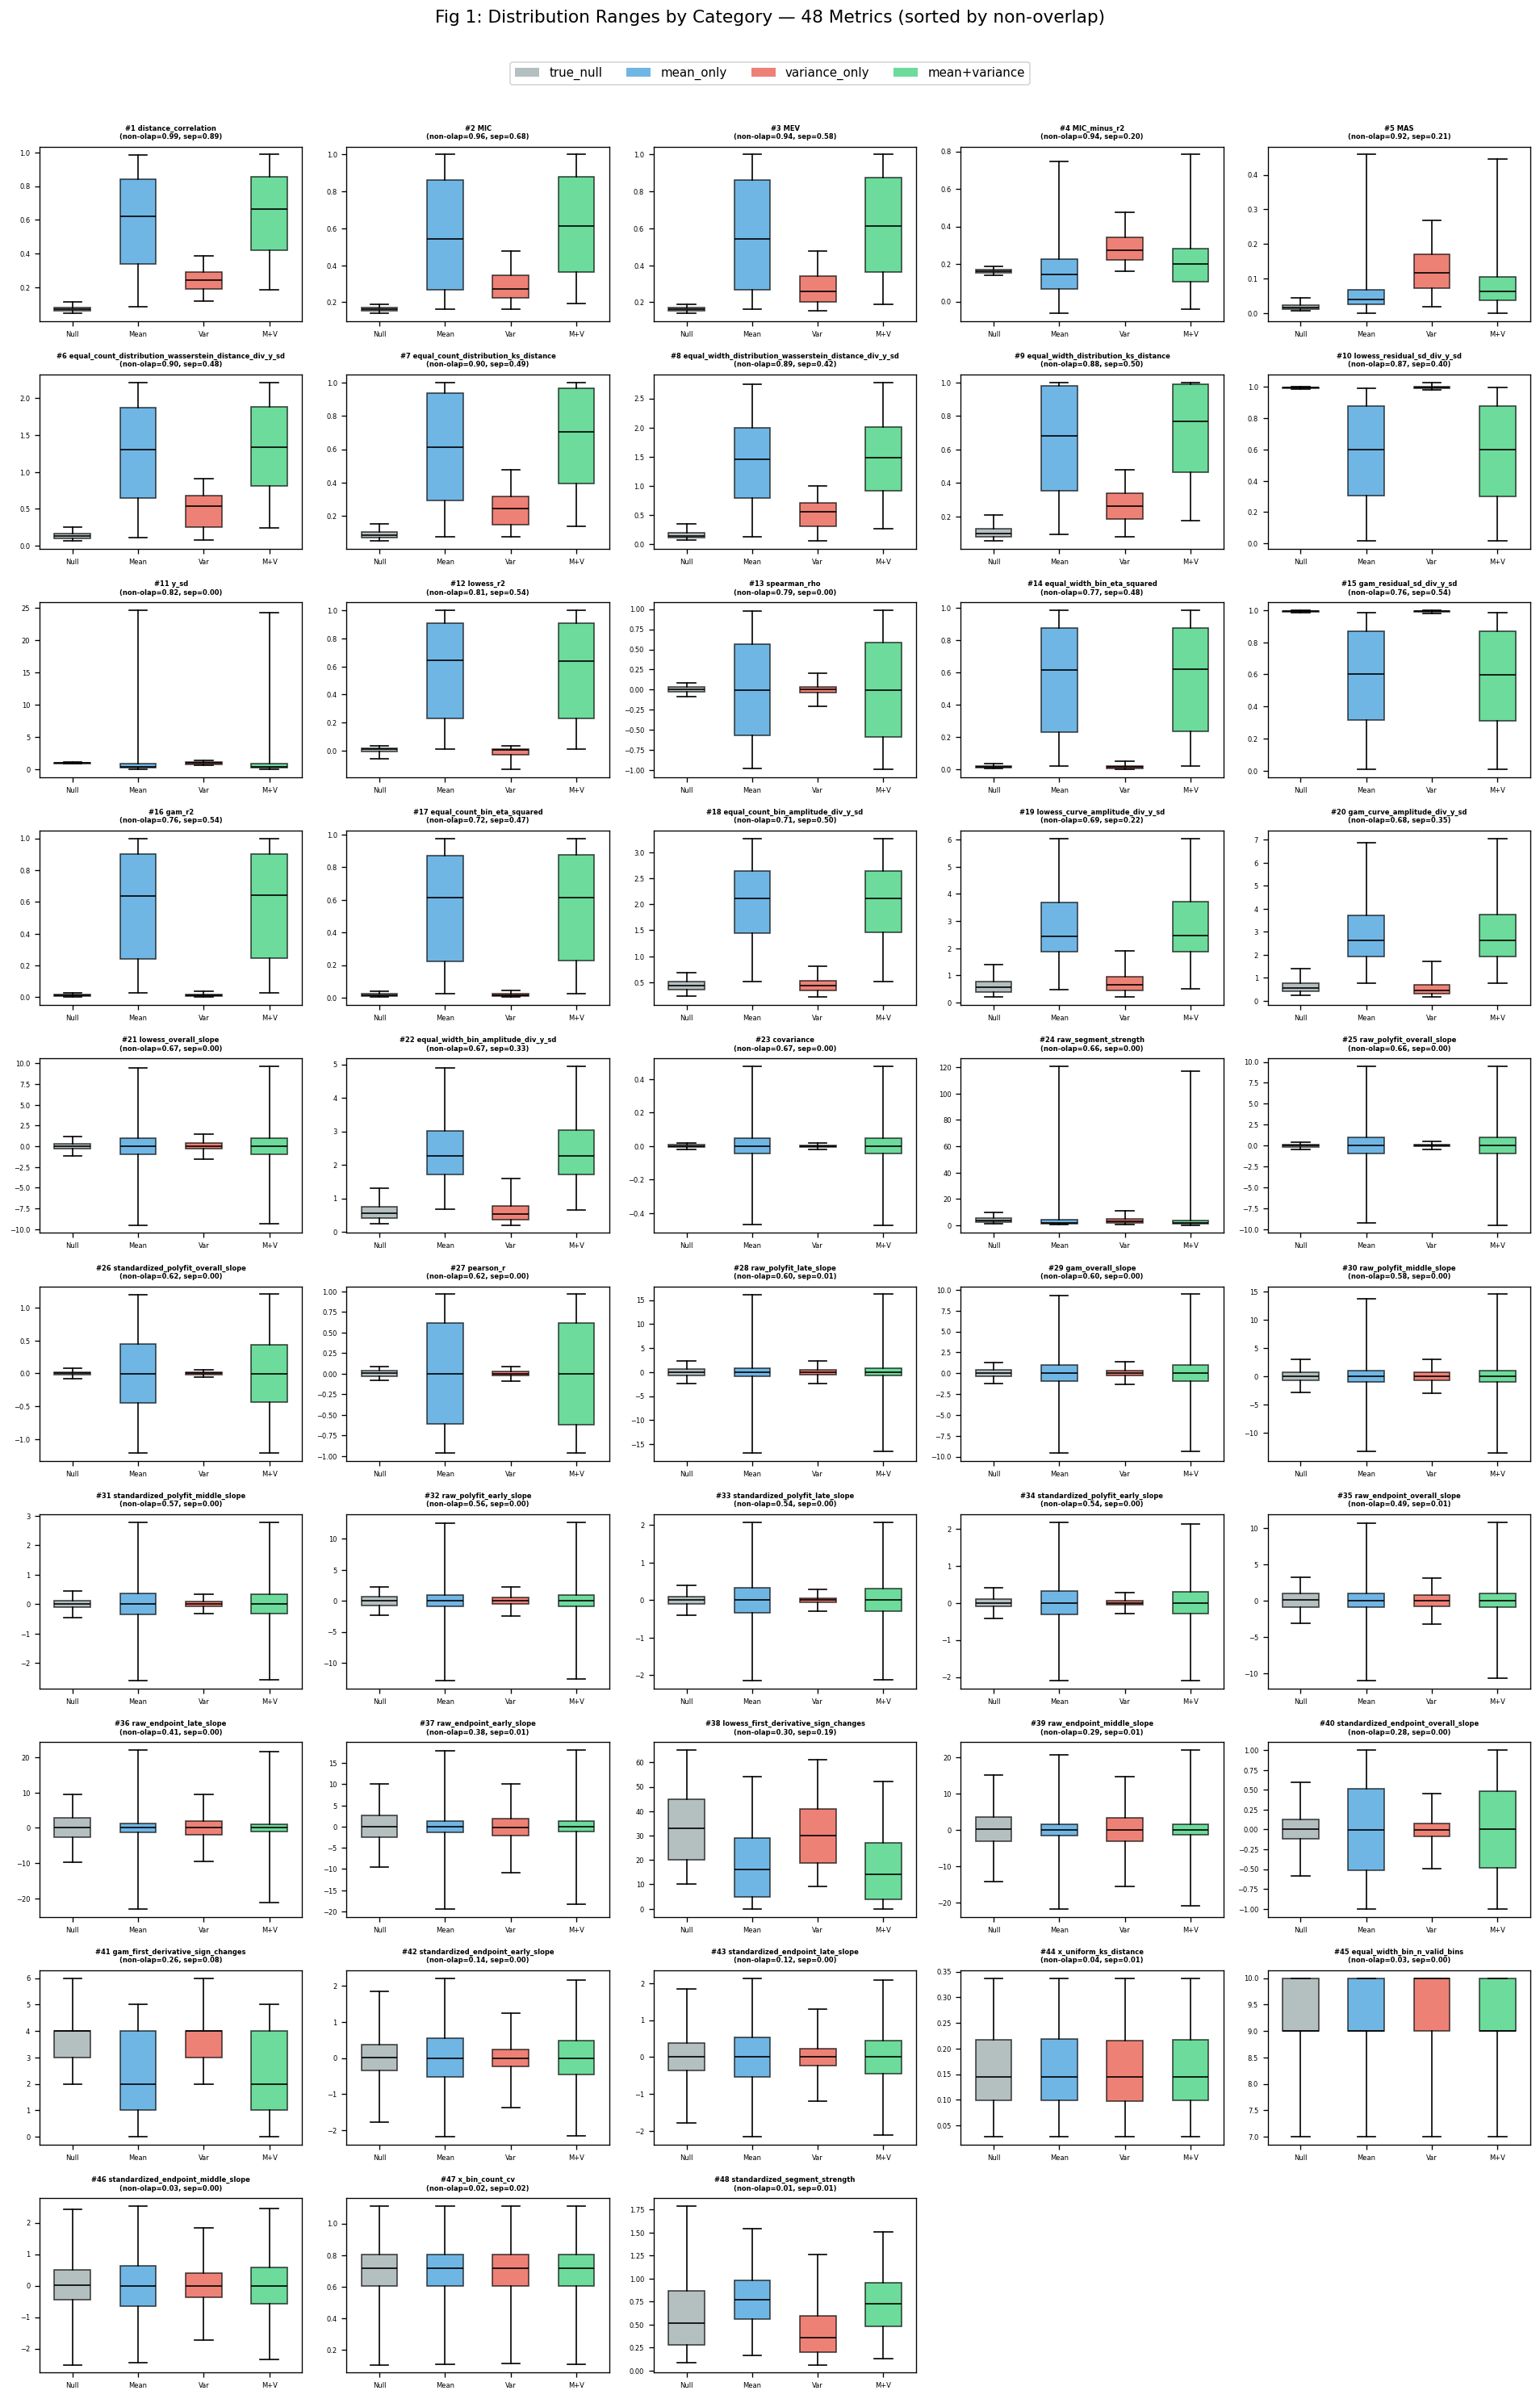

Saved → output/S2.4/fig1_range_by_category_all.png


In [49]:
from matplotlib.patches import Patch

cat_colors = {
    'true_null': '#95a5a6', 'mean_only': '#3498db',
    'variance_only': '#e74c3c', 'mean+variance': '#2ecc71',
}
cat_short = {
    'true_null': 'Null', 'mean_only': 'Mean',
    'variance_only': 'Var', 'mean+variance': 'M+V',
}

sorted_metrics = overall.index.tolist()
n_metrics = len(sorted_metrics)
n_cols = 5
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, n_rows * 2.4))
axes_flat = axes.flat

for idx, m in enumerate(sorted_metrics):
    ax = axes_flat[idx]
    box_data = []
    positions = []
    colors = []
    for j, cat in enumerate(categories):
        vals = df.loc[df['category'] == cat, m].dropna().values
        if len(vals) < 5:
            continue
        box_data.append(vals)
        positions.append(j)
        colors.append(cat_colors[cat])

    if box_data:
        bp = ax.boxplot(box_data, positions=positions, widths=0.55, patch_artist=True,
                        showfliers=False, medianprops={'color': 'black', 'linewidth': 1},
                        whis=[2.5, 97.5])
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels([cat_short[c] for c in categories], fontsize=5)
    score = overall.loc[m, 'mean_non_overlap']
    sep = overall.loc[m, 'mean_separation']
    ax.set_title(f'#{idx+1} {m}\n(non-olap={score:.2f}, sep={sep:.2f})', fontsize=5, fontweight='bold')
    ax.tick_params(axis='y', labelsize=5)

for idx in range(n_metrics, n_rows * n_cols):
    axes_flat[idx].set_visible(False)

legend_elements = [Patch(facecolor=cat_colors[c], alpha=0.7, label=c) for c in categories]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle(f'Fig 1: Distribution Ranges by Category — {n_metrics} Metrics (sorted by non-overlap)',
             fontsize=13, y=1.03)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig1_range_by_category_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig1_range_by_category_all.png"}')

## Fig 2: Non-Overlap Fraction Heatmap (metric × category)

For the top 30 metrics, show non-overlap fraction per signal category
(averaged across all x_distribution groups).
`non_overlap = 1 - overlap / signal_range` — how much of the signal range extends beyond null.
Note: high non-overlap does NOT mean clean separation — null may be buried inside a wide signal range.
Check `separation` column for strict two-way separation.

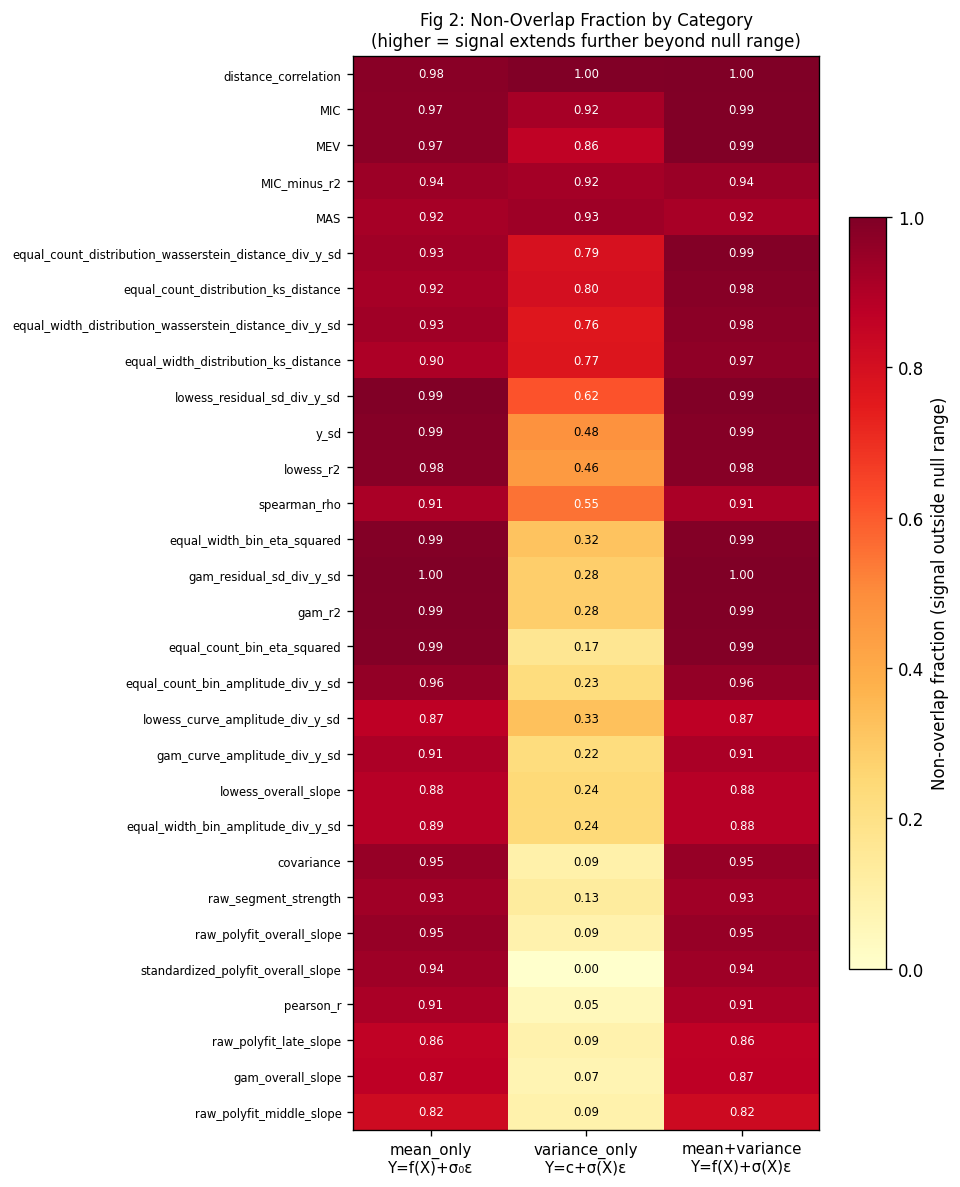

Saved → output/S2.4/fig2_non_overlap_by_category.png


In [50]:
# Pivot: non_overlap per metric × category (averaged over x_distribution)
cat_heat = comp_df.groupby(['metric', 'category'])['non_overlap_frac'].mean().reset_index()
cat_pivot = cat_heat.pivot(index='metric', columns='category', values='non_overlap_frac')
cat_pivot['mean'] = cat_pivot[signal_cats].mean(axis=1)
cat_pivot = cat_pivot.sort_values('mean', ascending=False)

top30 = cat_pivot.head(30)
plot_data = top30[signal_cats].values

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(plot_data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30.index, fontsize=7)
ax.set_xticks(range(len(signal_cats)))
ax.set_xticklabels(['mean_only\nY=f(X)+σ₀ε', 'variance_only\nY=c+σ(X)ε', 'mean+variance\nY=f(X)+σ(X)ε'], fontsize=9)

for i in range(plot_data.shape[0]):
    for j in range(plot_data.shape[1]):
        color = 'white' if plot_data[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{plot_data[i,j]:.2f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Non-overlap fraction (signal outside null range)', shrink=0.7)
ax.set_title('Fig 2: Non-Overlap Fraction by Category\n(higher = signal extends further beyond null range)', fontsize=10)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig2_non_overlap_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig2_non_overlap_by_category.png"}')

## Fig 3: Range Ratio Heatmap (metric × category)

signal_range_95 / null_range_95 per category: how much wider is the signal distribution?
A metric sensitive to mean-shift will show large ratio for mean_only; one sensitive to
variance-change will show large ratio for variance_only.

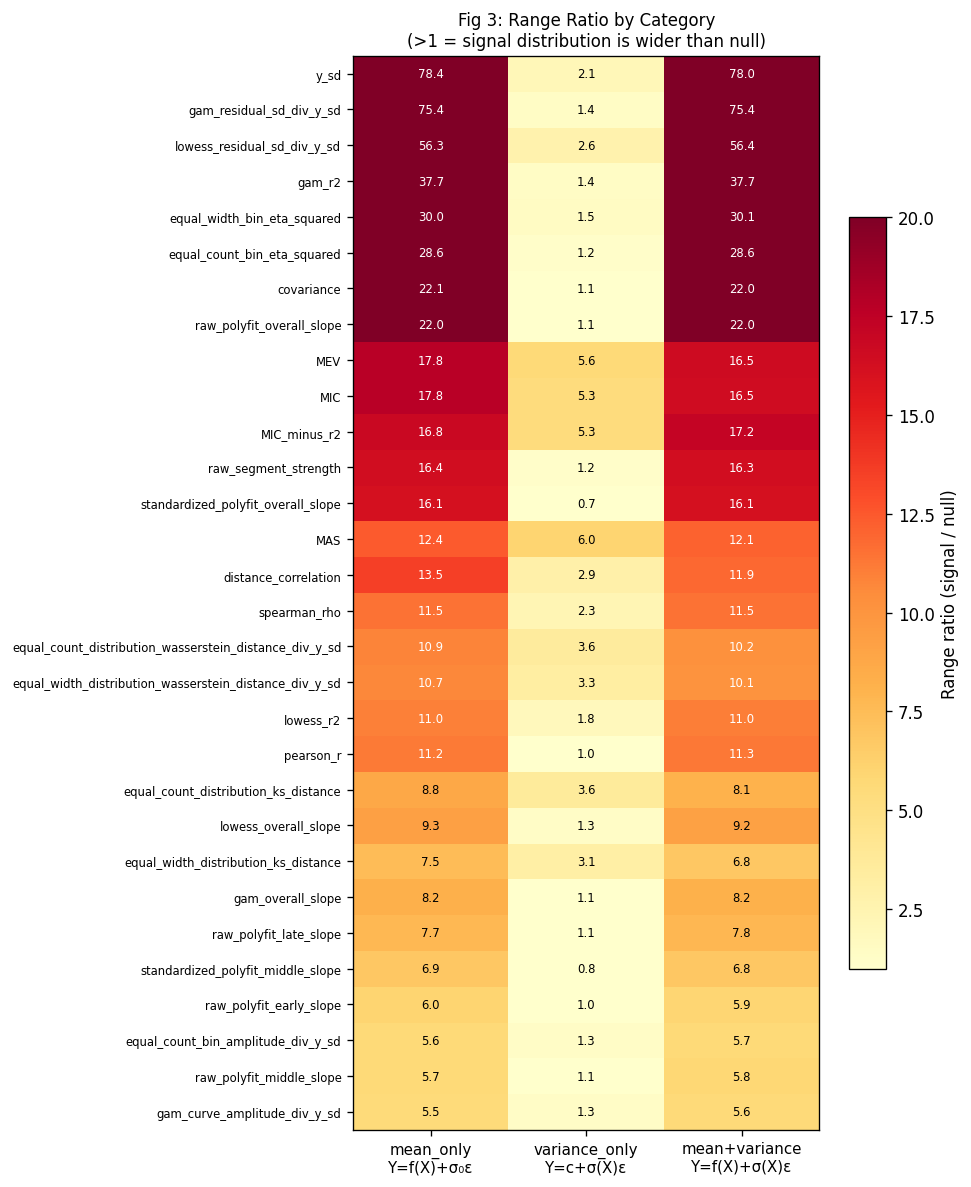

Saved → output/S2.4/fig3_range_ratio_by_category.png


In [51]:
ratio_by_cat = comp_df.groupby(['metric', 'category'])['range_ratio'].mean().reset_index()
ratio_cat_pivot = ratio_by_cat.pivot(index='metric', columns='category', values='range_ratio')
ratio_cat_pivot['mean'] = ratio_cat_pivot[signal_cats].mean(axis=1)
ratio_cat_pivot = ratio_cat_pivot.sort_values('mean', ascending=False)

top30_ratio = ratio_cat_pivot.head(30)
plot_data_r = top30_ratio[signal_cats].values

fig, ax = plt.subplots(figsize=(8, 10))
vmax = min(20, np.nanpercentile(plot_data_r, 95))
im = ax.imshow(plot_data_r, aspect='auto', cmap='YlOrRd', vmin=1, vmax=vmax)
ax.set_yticks(range(len(top30_ratio)))
ax.set_yticklabels(top30_ratio.index, fontsize=7)
ax.set_xticks(range(len(signal_cats)))
ax.set_xticklabels(['mean_only\nY=f(X)+σ₀ε', 'variance_only\nY=c+σ(X)ε', 'mean+variance\nY=f(X)+σ(X)ε'], fontsize=9)

for i in range(plot_data_r.shape[0]):
    for j in range(plot_data_r.shape[1]):
        v = plot_data_r[i, j]
        color = 'white' if v > vmax * 0.5 else 'black'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, label='Range ratio (signal / null)', shrink=0.7)
ax.set_title('Fig 3: Range Ratio by Category\n(>1 = signal distribution is wider than null)', fontsize=10)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig3_range_ratio_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig3_range_ratio_by_category.png"}')

## Fig 4: Best Metrics per Category — Top 15 per Signal Type

Three panels: for each signal category, show the top 15 metrics ranked by non-overlap fraction.

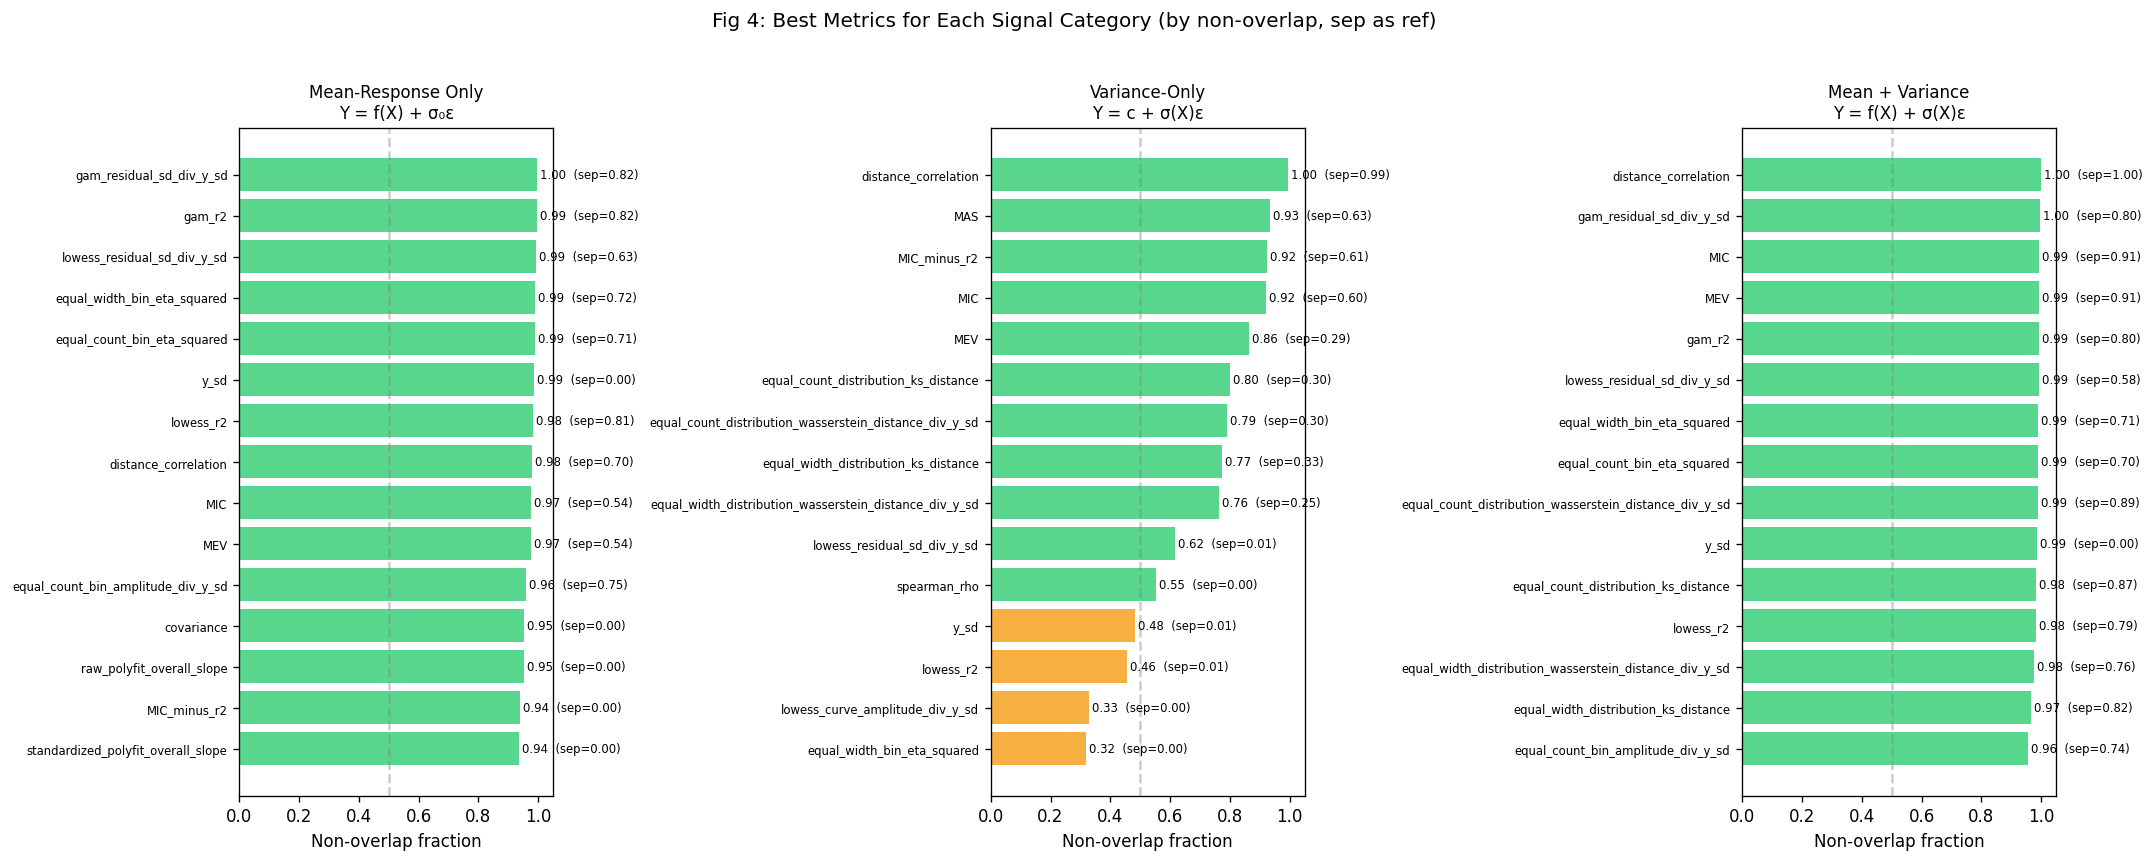

Saved → output/S2.4/fig4_best_per_category.png


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
cat_titles = {
    'mean_only': 'Mean-Response Only\nY = f(X) + σ₀ε',
    'variance_only': 'Variance-Only\nY = c + σ(X)ε',
    'mean+variance': 'Mean + Variance\nY = f(X) + σ(X)ε',
}

for ax, cat in zip(axes, signal_cats):
    cat_data = agg[agg['category'] == cat].sort_values('mean_non_overlap', ascending=False).head(15)
    vals = cat_data['mean_non_overlap'].values
    colors = ['#2ecc71' if v > 0.5 else '#f39c12' if v > 0.2 else '#e74c3c' for v in vals]

    ax.barh(range(len(cat_data)), vals, color=colors, alpha=0.8)
    for i, (_, row) in enumerate(cat_data.iterrows()):
        ax.text(row['mean_non_overlap'] + 0.01, i,
                f'{row["mean_non_overlap"]:.2f}  (sep={row["mean_separation"]:.2f})',
                va='center', fontsize=7)

    ax.set_yticks(range(len(cat_data)))
    ax.set_yticklabels(cat_data['metric'].values, fontsize=7)
    ax.set_xlabel('Non-overlap fraction')
    ax.set_title(cat_titles[cat], fontsize=10)
    ax.invert_yaxis()
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
    ax.set_xlim(0, 1.05)

plt.suptitle('Fig 4: Best Metrics for Each Signal Category (by non-overlap, sep as ref)', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig4_best_per_category.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig4_best_per_category.png"}')

## Fig 5: KDE Density

For each metric, overlay the 4 category density distributions.
Gray shaded band = null 95% range. Sorted by non-overlap (same order as Fig 1).

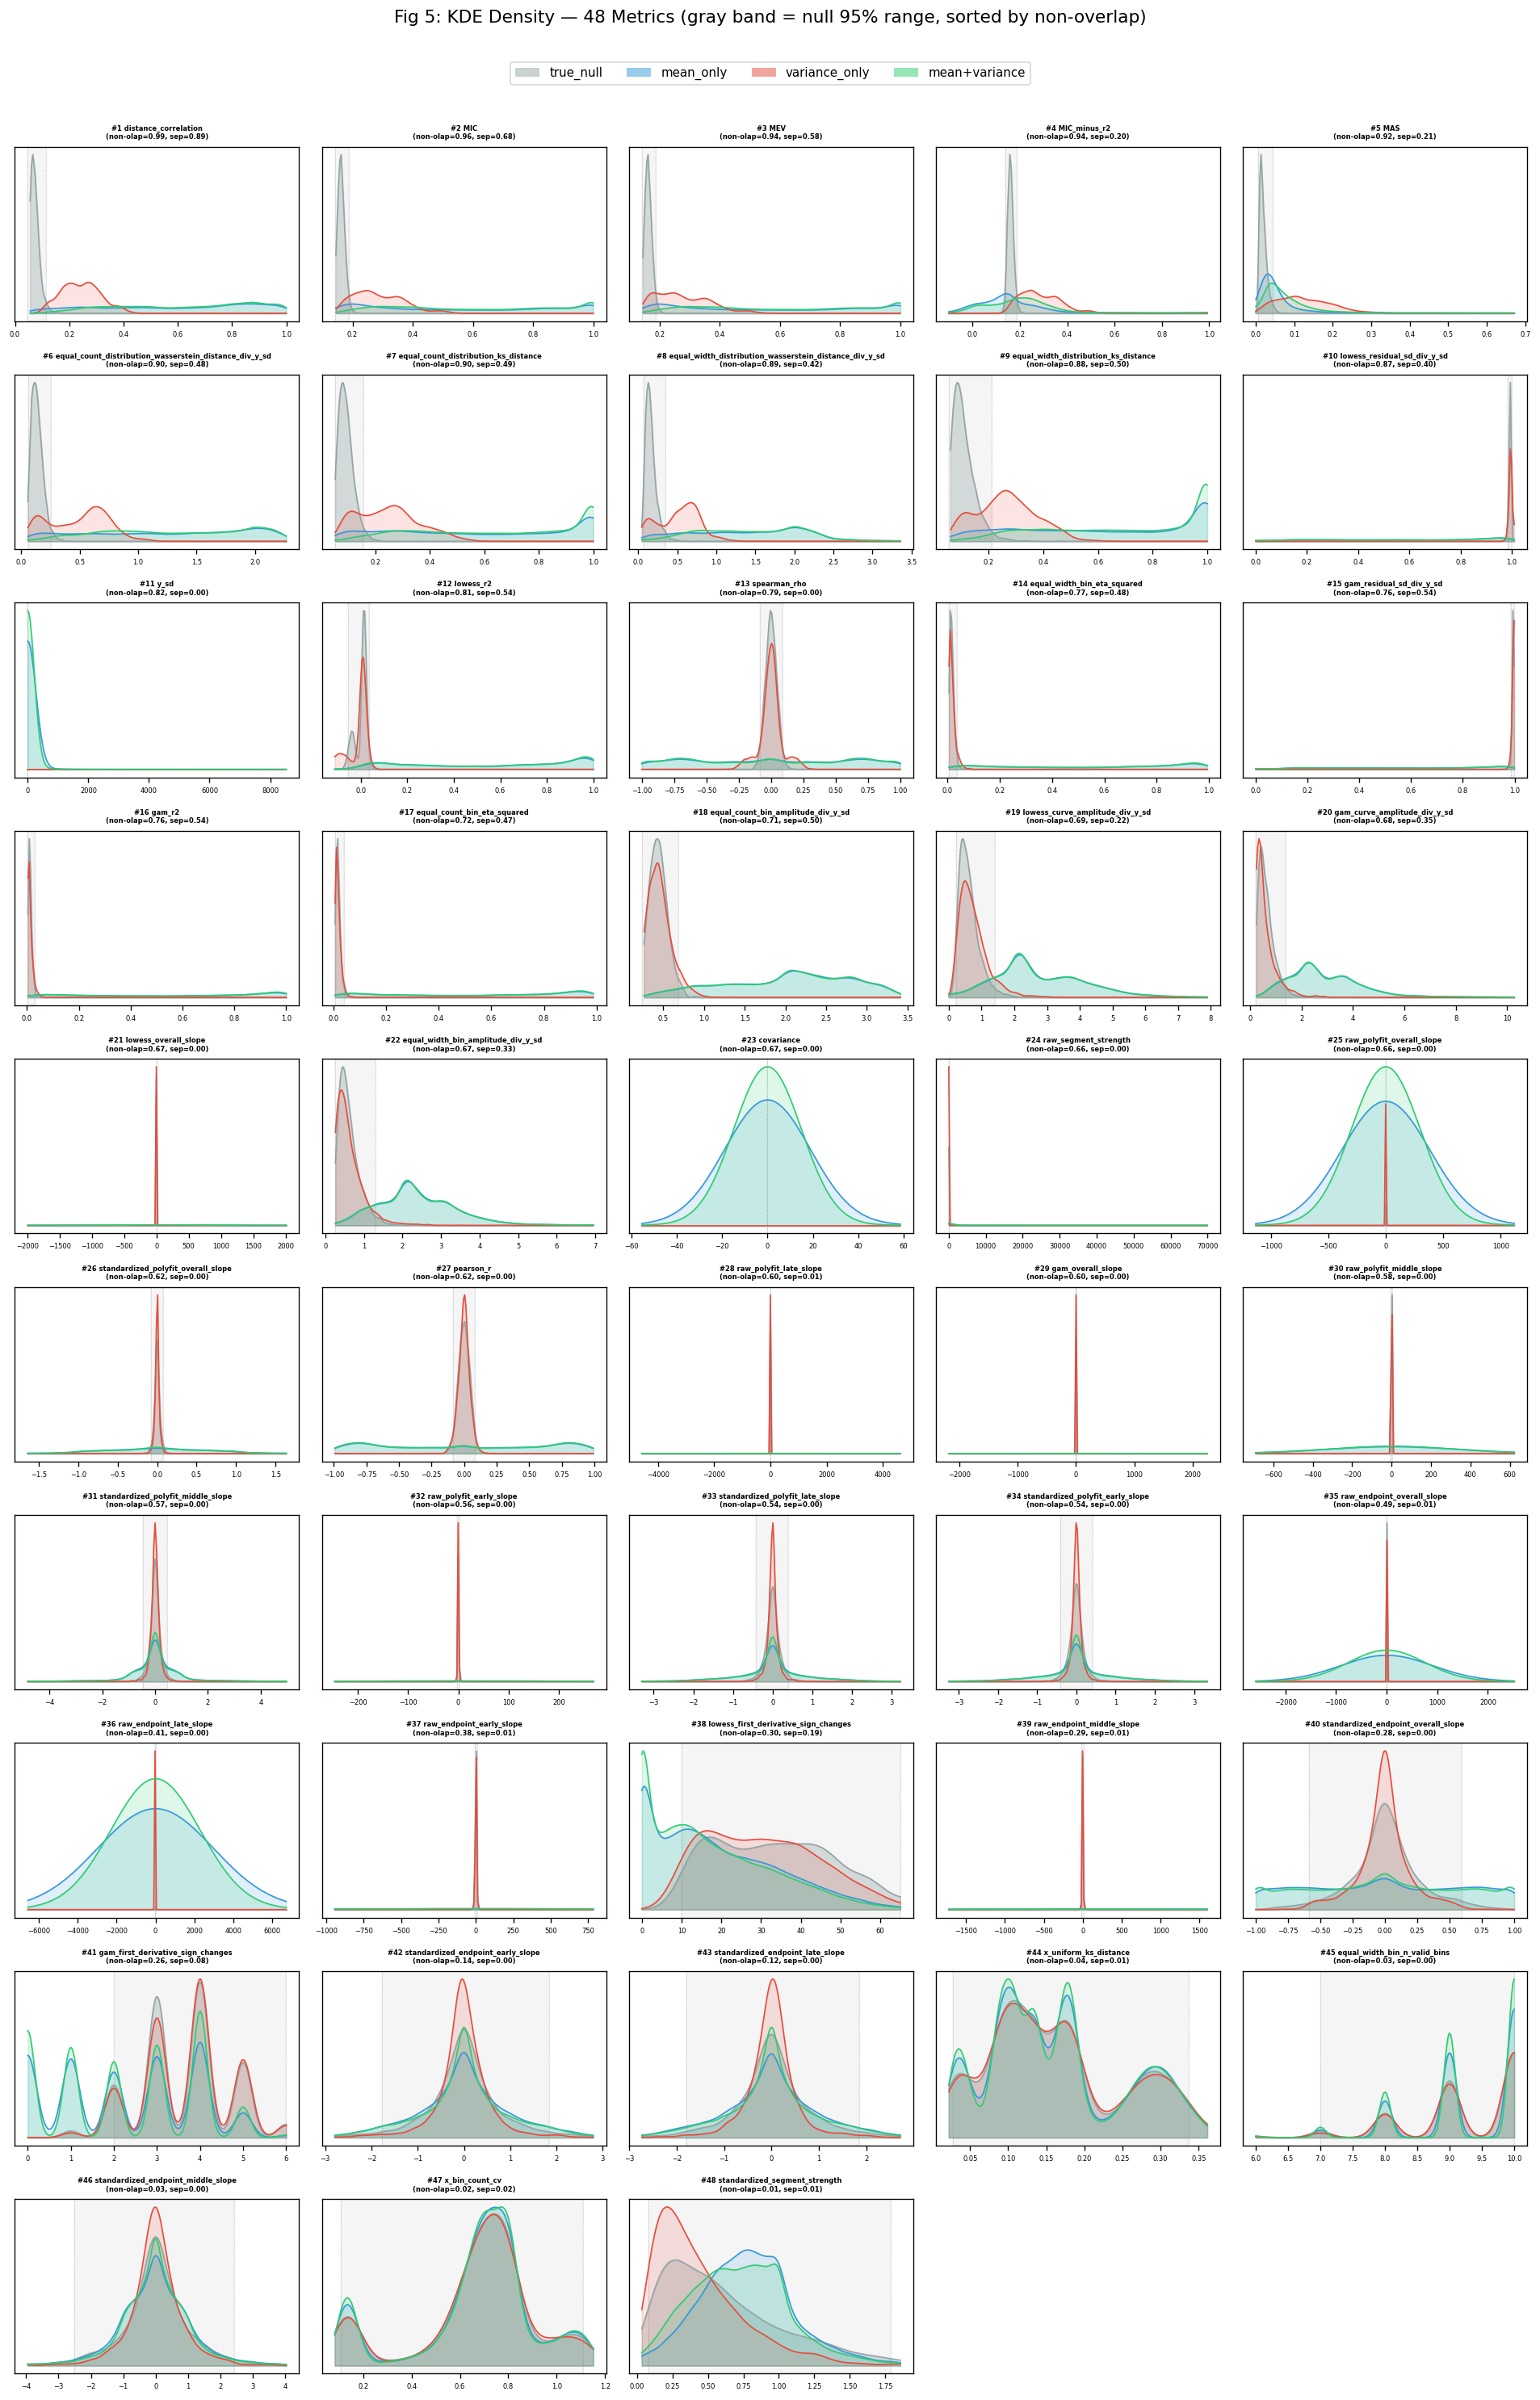

Saved → output/S2.4/fig5_kde_by_category_all.png


In [53]:
from scipy.stats import gaussian_kde

sorted_metrics_kde = overall.index.tolist()
n_metrics_kde = len(sorted_metrics_kde)
n_cols_kde = 5
n_rows_kde = int(np.ceil(n_metrics_kde / n_cols_kde))

fig, axes = plt.subplots(n_rows_kde, n_cols_kde, figsize=(n_cols_kde * 3.2, n_rows_kde * 2.4))
axes_flat = axes.flat

for idx, m in enumerate(sorted_metrics_kde):
    ax = axes_flat[idx]
    all_vals = df[m].dropna().values
    if len(all_vals) < 20:
        ax.set_title(f'#{idx+1} {m}\n(no data)', fontsize=5.5)
        continue
    x_lo = np.percentile(all_vals, 0.5)
    x_hi = np.percentile(all_vals, 99.5)
    x_grid = np.linspace(x_lo, x_hi, 200)

    for cat in categories:
        vals = df.loc[df['category'] == cat, m].dropna().values
        if len(vals) < 20:
            continue
        try:
            kde = gaussian_kde(vals)
            density = kde(x_grid)
            ax.fill_between(x_grid, density,
                            alpha=0.35 if cat == 'true_null' else 0.15,
                            color=cat_colors[cat])
            ax.plot(x_grid, density, color=cat_colors[cat], linewidth=1, label=cat)
        except Exception:
            continue

    null_vals = df.loc[df['category'] == 'true_null', m].dropna().values
    if len(null_vals) >= 5:
        lo, hi = np.percentile(null_vals, [2.5, 97.5])
        ax.axvspan(lo, hi, alpha=0.08, color='gray', zorder=0)
        ax.axvline(lo, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)
        ax.axvline(hi, color='gray', linestyle=':', linewidth=0.6, alpha=0.4)

    score = overall.loc[m, 'mean_non_overlap']
    sep = overall.loc[m, 'mean_separation']
    ax.set_title(f'#{idx+1} {m}\n(non-olap={score:.2f}, sep={sep:.2f})', fontsize=5, fontweight='bold')
    ax.tick_params(labelsize=5)
    ax.set_yticks([])

for idx in range(n_metrics_kde, n_rows_kde * n_cols_kde):
    axes_flat[idx].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cat_colors[c], alpha=0.5, label=c) for c in categories]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, 1.01))
plt.suptitle(f'Fig 5: KDE Density — {n_metrics_kde} Metrics (gray band = null 95% range, sorted by non-overlap)',
             fontsize=13, y=1.03)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig5_kde_by_category_all.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig5_kde_by_category_all.png"}')

## Fig 6: x_distribution Stability Check

For each signal category, show non-overlap fraction per x_distribution (top 15 metrics).
This answers: does the range separation hold across all x_distribution types,
or does it break down for certain distributions?

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_17869/451726048.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


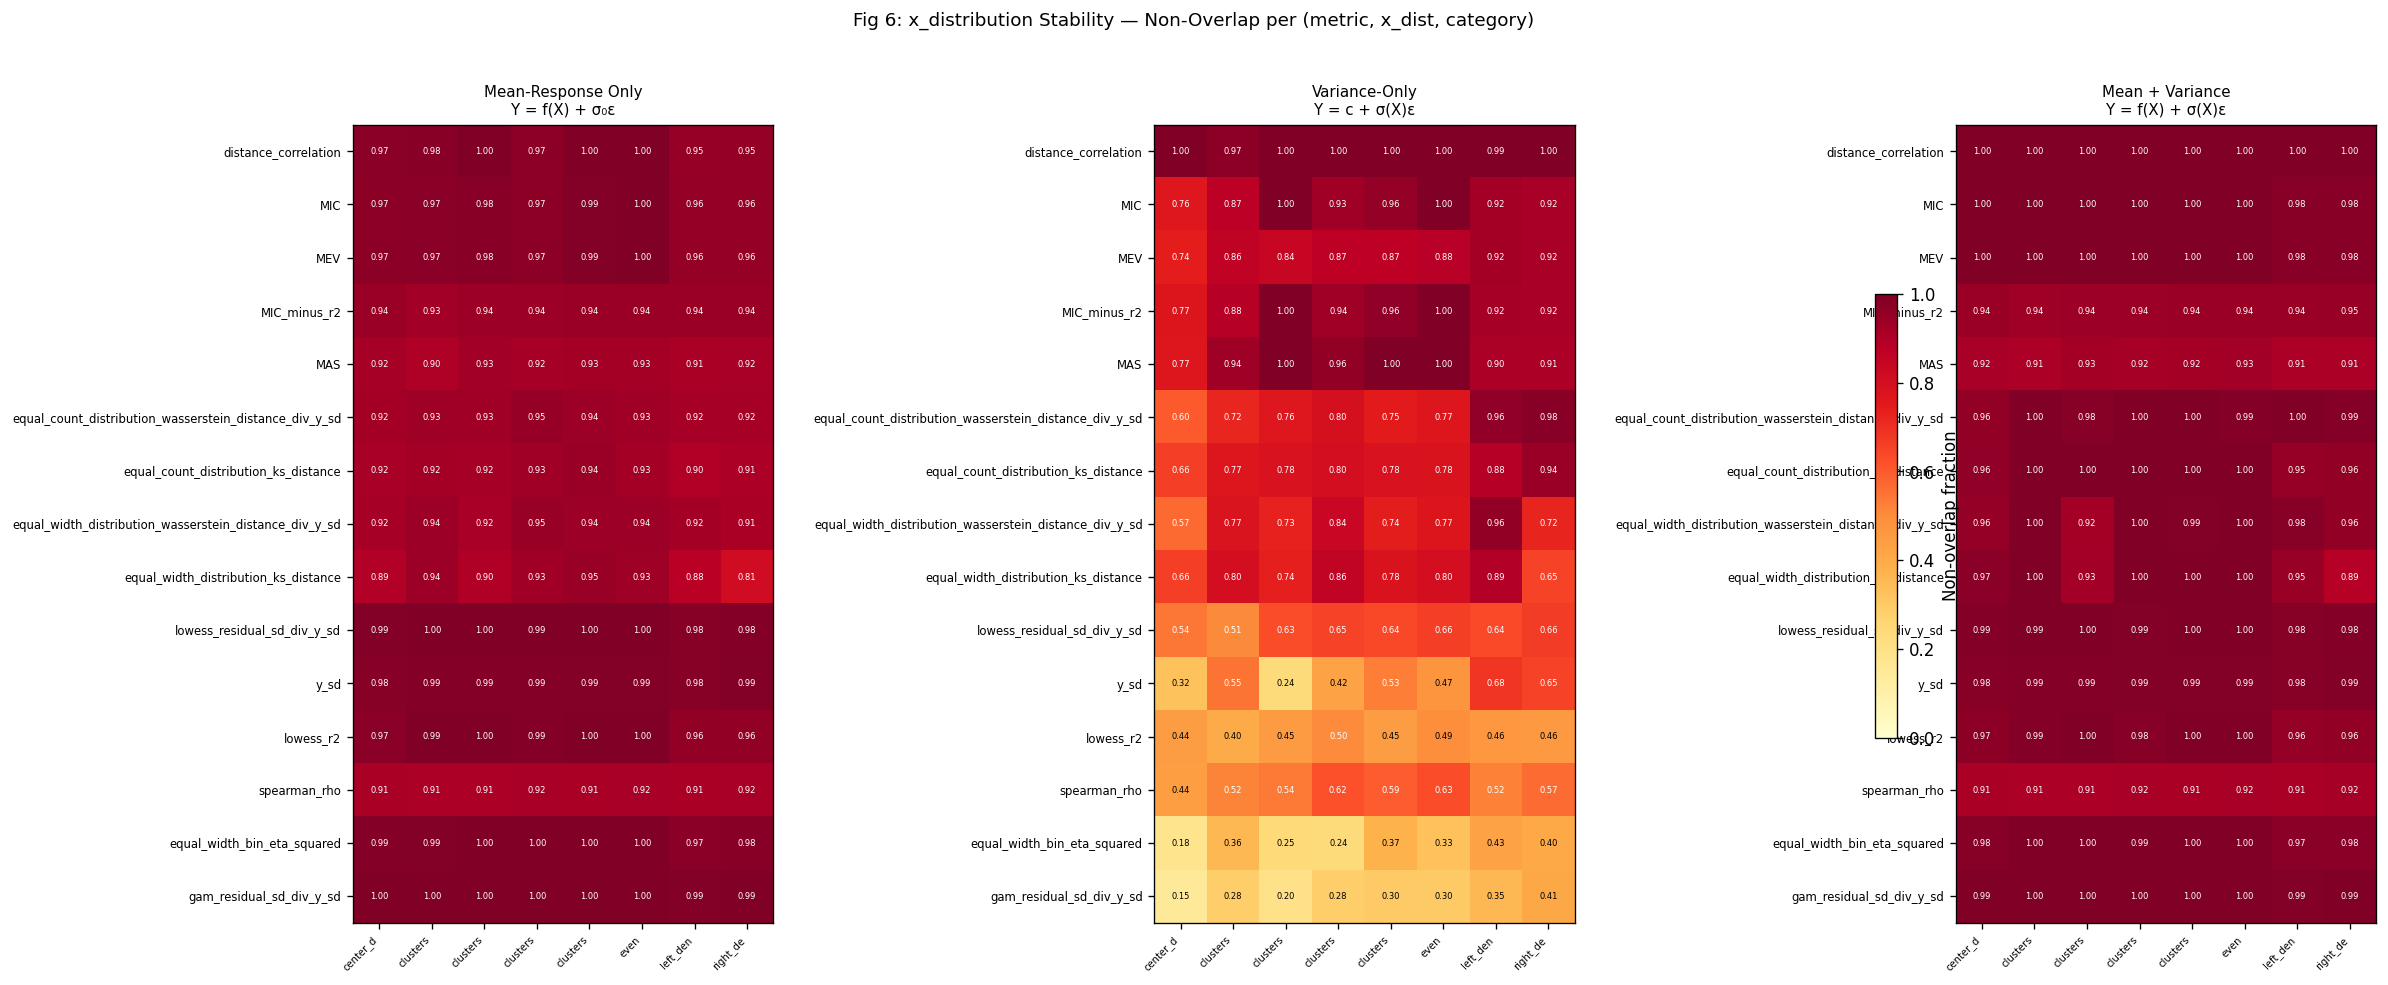

Saved → output/S2.4/fig6_xdist_stability.png


In [54]:
top15_overall = overall.head(15).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, cat in zip(axes, signal_cats):
    cat_data = comp_df[comp_df['category'] == cat]
    xd_pivot = cat_data.pivot_table(index='metric', columns='x_distribution',
                                     values='non_overlap_frac', aggfunc='mean')
    xd_pivot = xd_pivot.loc[[m for m in top15_overall if m in xd_pivot.index]]
    plot_d = xd_pivot[x_dists].values

    im = ax.imshow(plot_d, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_yticks(range(len(xd_pivot)))
    ax.set_yticklabels(xd_pivot.index, fontsize=7)
    ax.set_xticks(range(len(x_dists)))
    ax.set_xticklabels([xd[:8] for xd in x_dists], fontsize=6, rotation=45, ha='right')

    for i in range(plot_d.shape[0]):
        for j in range(plot_d.shape[1]):
            color = 'white' if plot_d[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{plot_d[i,j]:.2f}', ha='center', va='center', fontsize=5, color=color)

    ax.set_title(cat_titles[cat], fontsize=9)

plt.colorbar(im, ax=axes.tolist(), label='Non-overlap fraction', shrink=0.6)
plt.suptitle('Fig 6: x_distribution Stability — Non-Overlap per (metric, x_dist, category)',
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(VIZ_DIR / 'fig6_xdist_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {VIZ_DIR / "fig6_xdist_stability.png"}')

## Summary

In [55]:
print('=== Null vs Signal Range Analysis (Filtered) ===')
print(f'EXCLUDE_BANDWIDTH  = {EXCLUDE_BANDWIDTH}')
print(f'MERGE_DCOR_DCOV    = {MERGE_DCOR_DCOV}')
print(f'PREFER_DIV_Y_SD    = {PREFER_DIV_Y_SD}')
print(f'HIDE_NULL_CONSTANT = {HIDE_NULL_CONSTANT}')
print(f'Metrics displayed: {len(overall)}')
print()
print('Top 10 metrics (ranked by non-overlap, separation as reference):')
print(overall.head(10)[['mean_non_overlap', 'mean_separation', 'mean_median_shift']]
      .to_string(float_format='{:.3f}'.format))
print()
print('Per signal category — best metrics:')
for cat in signal_cats:
    cat_best = agg[agg['category'] == cat].sort_values('mean_non_overlap', ascending=False).head(5)
    print(f'\n  {cat}:')
    for _, row in cat_best.iterrows():
        print(f'    {row["metric"]:50s}  non_overlap={row["mean_non_overlap"]:.3f}  sep={row["mean_separation"]:.3f}')

# Save
overall.to_csv(VIZ_DIR / 'range_comparison_summary.csv', float_format='%.4f')
comp_df.to_csv(VIZ_DIR / 'range_comparisons_detail.csv', index=False, float_format='%.4f')
print(f'\nSaved → {VIZ_DIR}/')

=== Null vs Signal Range Analysis (Filtered) ===
EXCLUDE_BANDWIDTH  = True
MERGE_DCOR_DCOV    = True
PREFER_DIV_Y_SD    = True
HIDE_NULL_CONSTANT = True
Metrics displayed: 48

Top 10 metrics (ranked by non-overlap, separation as reference):
                                                        mean_non_overlap  mean_separation  mean_median_shift
metric                                                                                                      
distance_correlation                                               0.991            0.895              6.793
MIC                                                                0.963            0.682              6.837
MEV                                                                0.944            0.578              6.755
MIC_minus_r2                                                       0.935            0.205              1.201
MAS                                                                0.923            0.209              1.